In [1]:
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" "*15 + "NYC TAXI 2024 - MONTH BY MONTH PROCESSING")
print("="*70)

# Find all files
files = sorted(glob.glob('C:/DataAnalytics/NYC_Taxi_Analysis/data/raw/*.parquet'))
print(f"\n✅ Found {len(files)} files to process\n")

# Initialize storage for aggregated results
monthly_results = []
hourly_results = []
dow_results = []
payment_results = []

# Process each month
for month_num, file in enumerate(files, 1):
    filename = os.path.basename(file)
    print("="*70)
    print(f"[{month_num}/12] Processing: {filename}")
    print("="*70)
    
    # === STEP 1: LOAD ===
    print("  📥 Loading data...")
    df = pd.read_parquet(file)
    print(f"     Loaded: {len(df):,} rows")
    
    # === STEP 2: FILTER DATES ===
    print("  📅 Filtering to 2024...")
    df = df[
        (df['tpep_pickup_datetime'] >= '2024-01-01') &
        (df['tpep_pickup_datetime'] <= '2024-12-31')
    ].copy()
    print(f"     After date filter: {len(df):,} rows")
    
    # === STEP 3: HANDLE MISSING VALUES ===
    print("  🔧 Handling missing values...")
    df = df.fillna({
        'passenger_count': 1,
        'RatecodeID': 1,
        'Airport_fee': 0,
        'congestion_surcharge': 0,
        'store_and_fwd_flag': 'N'
    })
    
    # === STEP 4: CALCULATE TRIP DURATION ===
    df['trip_duration_minutes'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
    
    # === STEP 5: QUALITY FILTERS ===
    print("  🧹 Applying quality filters...")
    df = df[
        (df['fare_amount'] > 0) &
        (df['fare_amount'] < 500) &
        (df['trip_distance'] > 0) &
        (df['trip_distance'] < 100) &
        (df['passenger_count'] > 0) &
        (df['passenger_count'] <= 6) &
        (df['trip_duration_minutes'] > 0) &
        (df['trip_duration_minutes'] < 180)
    ].copy()
    print(f"     After quality filters: {len(df):,} rows")
    
    # === STEP 6: FEATURE ENGINEERING ===
    print("  ⚙️  Creating features...")
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
    df['tip_percentage'] = (df['tip_amount'] / df['fare_amount'] * 100).clip(0, 100)
    df['speed_mph'] = (df['trip_distance'] / (df['trip_duration_minutes'] / 60)).clip(0, 60)
    
    # === STEP 7: CALCULATE STATISTICS ===
    print("  📊 Calculating statistics...")
    
    # Monthly summary
    month_stat = {
        'month': df['pickup_month'].iloc[0],
        'trip_count': len(df),
        'total_revenue': df['total_amount'].sum(),
        'avg_fare': df['fare_amount'].mean(),
        'avg_distance': df['trip_distance'].mean(),
        'avg_duration': df['trip_duration_minutes'].mean(),
        'avg_tip_pct': df['tip_percentage'].mean(),
        'avg_speed': df['speed_mph'].mean(),
        'total_tips': df['tip_amount'].sum()
    }
    monthly_results.append(month_stat)
    
    # Hourly aggregation
    hourly = df.groupby('pickup_hour').agg({
        'VendorID': 'count',
        'fare_amount': 'mean',
        'trip_distance': 'mean',
        'tip_amount': 'mean',
        'speed_mph': 'mean'
    }).rename(columns={'VendorID': 'trip_count'}).reset_index()
    hourly['month'] = df['pickup_month'].iloc[0]
    hourly_results.append(hourly)
    
    # Day of week aggregation
    dow = df.groupby('pickup_dayofweek').agg({
        'VendorID': 'count',
        'fare_amount': 'mean',
        'total_amount': 'sum',
        'trip_distance': 'mean'
    }).rename(columns={'VendorID': 'trip_count'}).reset_index()
    dow['month'] = df['pickup_month'].iloc[0]
    dow_results.append(dow)
    
    # Payment type aggregation
    payment = df.groupby('payment_type').agg({
        'VendorID': 'count',
        'fare_amount': 'mean',
        'tip_amount': 'mean',
        'total_amount': 'sum'
    }).rename(columns={'VendorID': 'trip_count'}).reset_index()
    payment['month'] = df['pickup_month'].iloc[0]
    payment_results.append(payment)
    
    print(f"  ✅ Month {month_num} complete!")
    print(f"     Trips: {len(df):,} | Revenue: ${df['total_amount'].sum():,.2f}")
    
    # === STEP 8: FREE MEMORY ===
    del df
    import gc
    gc.collect()
    print(f"  🗑️  Memory cleared\n")

# === COMBINE ALL RESULTS ===
print("="*70)
print("COMBINING ALL MONTHS")
print("="*70)

# Monthly DataFrame
monthly_df = pd.DataFrame(monthly_results)
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_df['month_name'] = monthly_df['month'].map(month_names)

# Hourly DataFrame (aggregate across all months)
hourly_combined = pd.concat(hourly_results, ignore_index=True)
hourly_df = hourly_combined.groupby('pickup_hour').agg({
    'trip_count': 'sum',
    'fare_amount': 'mean',
    'trip_distance': 'mean',
    'tip_amount': 'mean',
    'speed_mph': 'mean'
}).reset_index()

# Day of Week DataFrame
dow_combined = pd.concat(dow_results, ignore_index=True)
dow_df = dow_combined.groupby('pickup_dayofweek').agg({
    'trip_count': 'sum',
    'fare_amount': 'mean',
    'total_amount': 'sum',
    'trip_distance': 'mean'
}).reset_index()
day_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
dow_df['day_name'] = dow_df['pickup_dayofweek'].map(day_names)

# Payment Type DataFrame
payment_combined = pd.concat(payment_results, ignore_index=True)
payment_df = payment_combined.groupby('payment_type').agg({
    'trip_count': 'sum',
    'fare_amount': 'mean',
    'tip_amount': 'mean',
    'total_amount': 'sum'
}).reset_index()

print("\n✅ All results combined successfully!\n")

# === FINAL SUMMARY ===
print("="*70)
print(" "*20 + "🎉 FULL YEAR 2024 SUMMARY 🎉")
print("="*70)
print(f"\n📊 OVERALL STATISTICS:")
print(f"   Total Trips:        {monthly_df['trip_count'].sum():>15,}")
print(f"   Total Revenue:      ${monthly_df['total_revenue'].sum():>14,.2f}")
print(f"   Total Tips:         ${monthly_df['total_tips'].sum():>14,.2f}")
print(f"   Average Fare:       ${monthly_df['avg_fare'].mean():>14.2f}")
print(f"   Average Distance:   {monthly_df['avg_distance'].mean():>14.2f} miles")
print(f"   Average Duration:   {monthly_df['avg_duration'].mean():>14.1f} minutes")
print(f"   Average Speed:      {monthly_df['avg_speed'].mean():>14.1f} mph")
print(f"   Average Tip %:      {monthly_df['avg_tip_pct'].mean():>14.1f}%")

print(f"\n📅 MONTHLY BREAKDOWN:")
print(monthly_df[['month_name', 'trip_count', 'total_revenue', 'avg_fare']].to_string(index=False))

print(f"\n🏆 HIGHLIGHTS:")
busiest_month = monthly_df.loc[monthly_df['trip_count'].idxmax()]
print(f"   Busiest Month:      {busiest_month['month_name']} ({busiest_month['trip_count']:,} trips)")
highest_revenue = monthly_df.loc[monthly_df['total_revenue'].idxmax()]
print(f"   Highest Revenue:    {highest_revenue['month_name']} (${highest_revenue['total_revenue']:,.2f})")
busiest_hour = hourly_df.loc[hourly_df['trip_count'].idxmax()]
print(f"   Busiest Hour:       {int(busiest_hour['pickup_hour'])}:00 ({busiest_hour['trip_count']:,} trips)")
busiest_day = dow_df.loc[dow_df['trip_count'].idxmax()]
print(f"   Busiest Day:        {busiest_day['day_name']} ({busiest_day['trip_count']:,} trips)")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE! Ready for visualizations!")
print("="*70)

               NYC TAXI 2024 - MONTH BY MONTH PROCESSING

✅ Found 12 files to process

[1/12] Processing: yellow_tripdata_2024-01.parquet
  📥 Loading data...
     Loaded: 2,964,624 rows
  📅 Filtering to 2024...
     After date filter: 2,964,609 rows
  🔧 Handling missing values...
  🧹 Applying quality filters...
     After quality filters: 2,836,874 rows
  ⚙️  Creating features...
  📊 Calculating statistics...
  ✅ Month 1 complete!
     Trips: 2,836,874 | Revenue: $77,616,433.16
  🗑️  Memory cleared

[2/12] Processing: yellow_tripdata_2024-02.parquet
  📥 Loading data...
     Loaded: 3,007,526 rows
  📅 Filtering to 2024...
     After date filter: 3,007,524 rows
  🔧 Handling missing values...
  🧹 Applying quality filters...
     After quality filters: 2,866,510 rows
  ⚙️  Creating features...
  📊 Calculating statistics...
  ✅ Month 2 complete!
     Trips: 2,866,510 | Revenue: $78,137,429.59
  🗑️  Memory cleared

[3/12] Processing: yellow_tripdata_2024-03.parquet
  📥 Loading data...
     L

VISUALIZATION 1: MONTHLY TRENDS


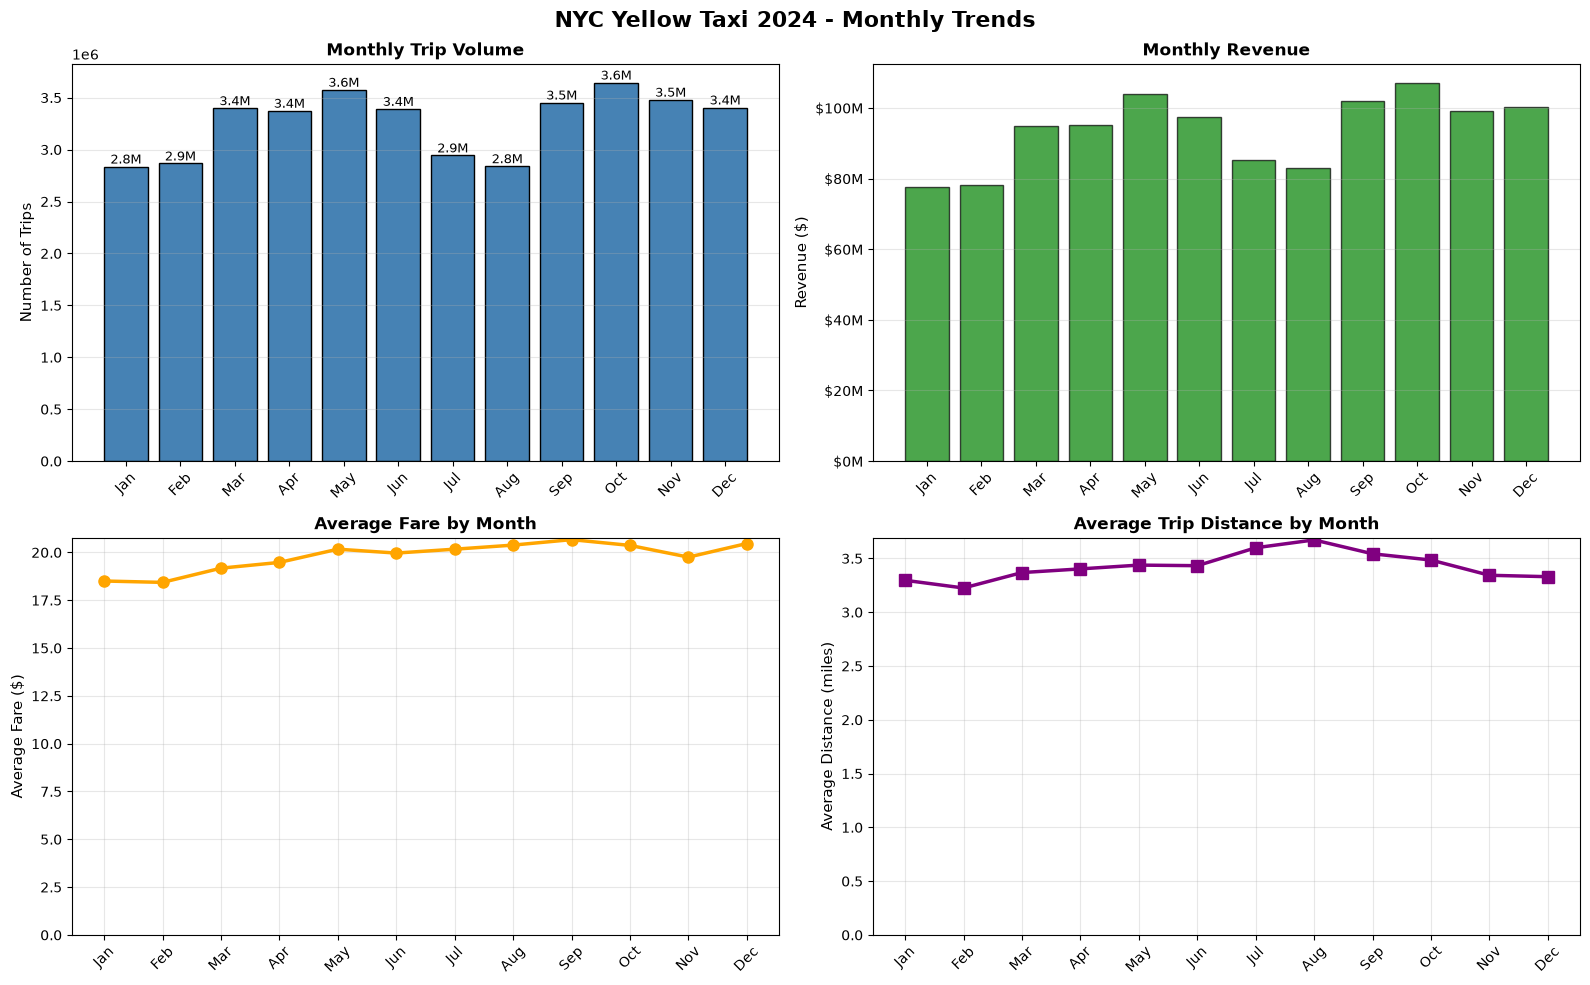

✅ Monthly trends visualization complete!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("VISUALIZATION 1: MONTHLY TRENDS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NYC Yellow Taxi 2024 - Monthly Trends', fontsize=16, fontweight='bold')

# Trip Volume
axes[0, 0].bar(monthly_df['month_name'], monthly_df['trip_count'], color='steelblue', edgecolor='black')
axes[0, 0].set_ylabel('Number of Trips', fontsize=11)
axes[0, 0].set_title('Monthly Trip Volume', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
# Add value labels
for i, v in enumerate(monthly_df['trip_count']):
    axes[0, 0].text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# Revenue
axes[0, 1].bar(monthly_df['month_name'], monthly_df['total_revenue'], color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Revenue ($)', fontsize=11)
axes[0, 1].set_title('Monthly Revenue', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
# Format y-axis as millions
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Average Fare
axes[1, 0].plot(monthly_df['month_name'], monthly_df['avg_fare'], 
                marker='o', linewidth=2.5, color='orange', markersize=8)
axes[1, 0].set_ylabel('Average Fare ($)', fontsize=11)
axes[1, 0].set_title('Average Fare by Month', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylim(bottom=0)

# Average Distance
axes[1, 1].plot(monthly_df['month_name'], monthly_df['avg_distance'], 
                marker='s', linewidth=2.5, color='purple', markersize=8)
axes[1, 1].set_ylabel('Average Distance (miles)', fontsize=11)
axes[1, 1].set_title('Average Trip Distance by Month', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("✅ Monthly trends visualization complete!")


VISUALIZATION 2: HOURLY PATTERNS


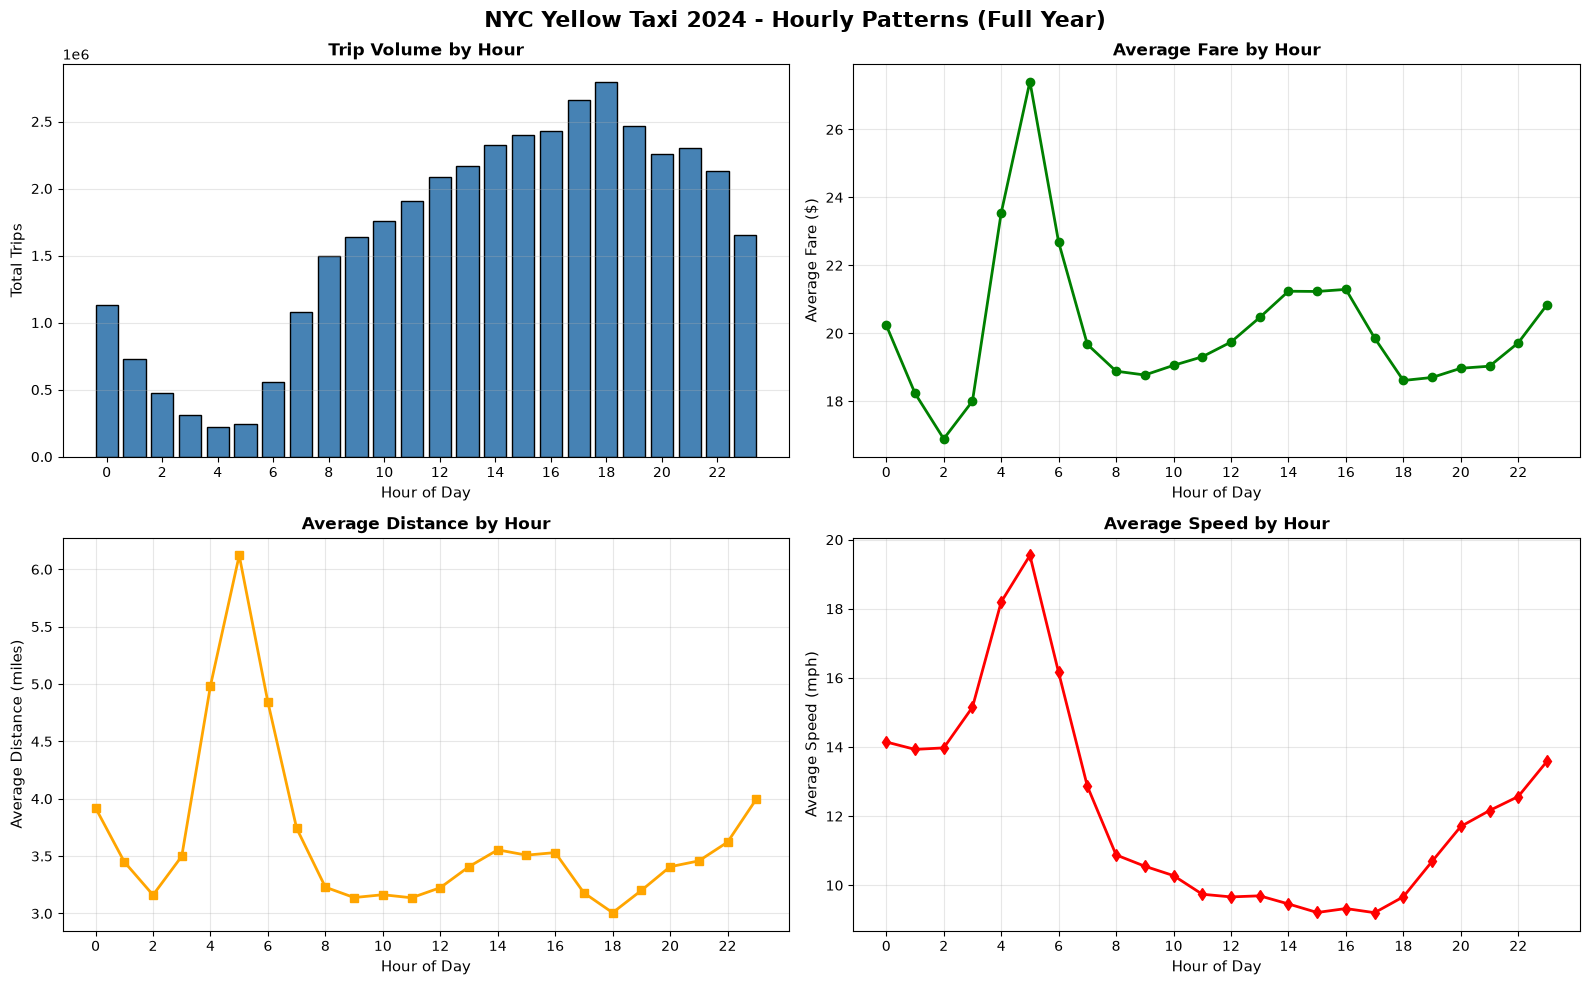

✅ Hourly patterns visualization complete!


In [3]:
print("\n" + "="*60)
print("VISUALIZATION 2: HOURLY PATTERNS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NYC Yellow Taxi 2024 - Hourly Patterns (Full Year)', fontsize=16, fontweight='bold')

# Trip Volume by Hour
axes[0, 0].bar(hourly_df['pickup_hour'], hourly_df['trip_count'], color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Hour of Day', fontsize=11)
axes[0, 0].set_ylabel('Total Trips', fontsize=11)
axes[0, 0].set_title('Trip Volume by Hour', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Average Fare by Hour
axes[0, 1].plot(hourly_df['pickup_hour'], hourly_df['fare_amount'], 
                marker='o', linewidth=2, color='green', markersize=6)
axes[0, 1].set_xlabel('Hour of Day', fontsize=11)
axes[0, 1].set_ylabel('Average Fare ($)', fontsize=11)
axes[0, 1].set_title('Average Fare by Hour', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 2))

# Average Distance by Hour
axes[1, 0].plot(hourly_df['pickup_hour'], hourly_df['trip_distance'], 
                marker='s', linewidth=2, color='orange', markersize=6)
axes[1, 0].set_xlabel('Hour of Day', fontsize=11)
axes[1, 0].set_ylabel('Average Distance (miles)', fontsize=11)
axes[1, 0].set_title('Average Distance by Hour', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(0, 24, 2))

# Average Speed by Hour
axes[1, 1].plot(hourly_df['pickup_hour'], hourly_df['speed_mph'], 
                marker='d', linewidth=2, color='red', markersize=6)
axes[1, 1].set_xlabel('Hour of Day', fontsize=11)
axes[1, 1].set_ylabel('Average Speed (mph)', fontsize=11)
axes[1, 1].set_title('Average Speed by Hour', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("✅ Hourly patterns visualization complete!")


VISUALIZATION 3: DAY OF WEEK ANALYSIS


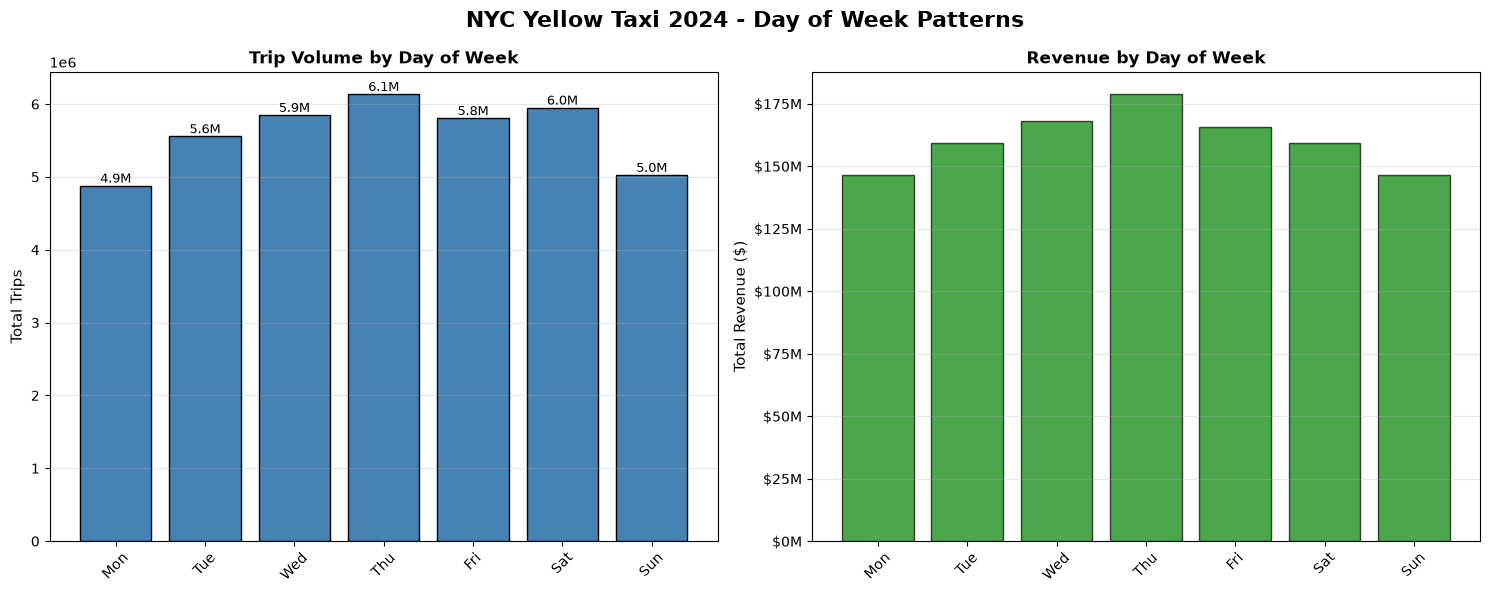

✅ Day of week visualization complete!


In [4]:
print("\n" + "="*60)
print("VISUALIZATION 3: DAY OF WEEK ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('NYC Yellow Taxi 2024 - Day of Week Patterns', fontsize=16, fontweight='bold')

# Trip Volume by Day
axes[0].bar(dow_df['day_name'], dow_df['trip_count'], color='steelblue', edgecolor='black')
axes[0].set_ylabel('Total Trips', fontsize=11)
axes[0].set_title('Trip Volume by Day of Week', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
# Add value labels
for i, v in enumerate(dow_df['trip_count']):
    axes[0].text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# Revenue by Day
axes[1].bar(dow_df['day_name'], dow_df['total_amount'], color='green', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Total Revenue ($)', fontsize=11)
axes[1].set_title('Revenue by Day of Week', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

print("✅ Day of week visualization complete!")


VISUALIZATION 4: PAYMENT TYPE ANALYSIS


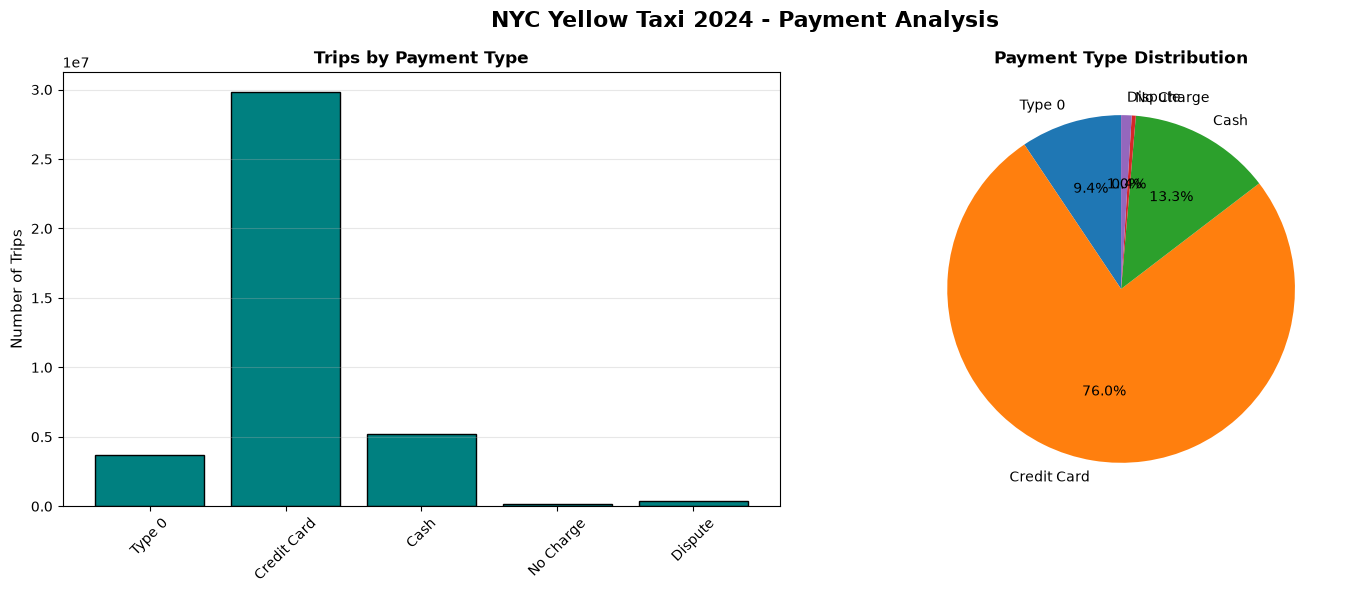

✅ Payment type visualization complete!


In [5]:
print("\n" + "="*60)
print("VISUALIZATION 4: PAYMENT TYPE ANALYSIS")
print("="*60)

# Map payment types
payment_names = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 
                 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
payment_df['payment_name'] = payment_df['payment_type'].map(
    lambda x: payment_names.get(x, f'Type {x}')
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('NYC Yellow Taxi 2024 - Payment Analysis', fontsize=16, fontweight='bold')

# Trip Count by Payment Type
axes[0].bar(payment_df['payment_name'], payment_df['trip_count'], color='teal', edgecolor='black')
axes[0].set_ylabel('Number of Trips', fontsize=11)
axes[0].set_title('Trips by Payment Type', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie Chart
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
axes[1].pie(payment_df['trip_count'], labels=payment_df['payment_name'], 
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Payment Type Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Payment type visualization complete!")

In [6]:
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save summary statistics
monthly_df.to_csv('nyc_taxi_2024_monthly_summary.csv', index=False)
print("✅ Saved: nyc_taxi_2024_monthly_summary.csv")

hourly_df.to_csv('nyc_taxi_2024_hourly_summary.csv', index=False)
print("✅ Saved: nyc_taxi_2024_hourly_summary.csv")

dow_df.to_csv('nyc_taxi_2024_dow_summary.csv', index=False)
print("✅ Saved: nyc_taxi_2024_dow_summary.csv")

payment_df.to_csv('nyc_taxi_2024_payment_summary.csv', index=False)
print("✅ Saved: nyc_taxi_2024_payment_summary.csv")

print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE! ALL FILES SAVED!")
print("="*60)


SAVING RESULTS
✅ Saved: nyc_taxi_2024_monthly_summary.csv
✅ Saved: nyc_taxi_2024_hourly_summary.csv
✅ Saved: nyc_taxi_2024_dow_summary.csv
✅ Saved: nyc_taxi_2024_payment_summary.csv

🎉 ANALYSIS COMPLETE! ALL FILES SAVED!


In [7]:
# Run this to save all your charts
import matplotlib.pyplot as plt

# Re-run each visualization, then add at the end:
plt.savefig('monthly_trends.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>